In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load image
img_path = 'monarch_in.jpg'

In [2]:
# ── Convolution
# Slides kernel over every pixel. At each spot: multiply overlapping values,
# sum to one number → that becomes the new pixel. Same-padding keeps output
# size identical to input.
def convolve(img, K):
    ph, pw = K.shape[0]//2, K.shape[1]//2
    p = np.pad(img, ((ph,ph),(pw,pw))) # padding same
    return np.array([[np.sum(p[i:i+K.shape[0], j:j+K.shape[1]] * K)
                      for j in range(img.shape[1])] for i in range(img.shape[0])])

In [3]:
# ── Normalise
# Shifts output to [0,1] so all filters are visually comparable regardless of
# their raw magnitude (Laplacian produces negatives; Roberts produces tiny values)
norm = lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)

In [4]:
# ── Kernels & names
# Each kernel is a small matrix of weights. The pattern of +1/-1 determines
# WHAT the filter responds to (edges, directions, curvature).
def gradient(img, Kx, Ky):
    # Two kernels → two directional responses → combine as vector magnitude
    # √(Gx²+Gy²) gives edge strength regardless of orientation
    return norm(np.sqrt(convolve(img,Kx)**2 + convolve(img,Ky)**2))

### Edge Detection: Where does the image intensity change?

* Vertical edge detection: $$
G_x = \begin{bmatrix}
-1 & 0 & 1 \\
-1 & 0 & 1 \\
-1 & 0 & 1
\end{bmatrix}
$$
So at each pixel: Looks at left column vs right column
If there's a big difference → edge

* Vertical edge detection: $$
G_y = \begin{bmatrix}
-1 & -1 & -1 \\
0 & 0 & 0 \\
1 & 1 & 1
\end{bmatrix}
$$


* Prewitt Operator (Gx + Gy): Instead of choosing one direction compute both:  horizontal change (Gx) vertical change (Gy) then combine:
$$G = \sqrt{G_x^2 + G_y^2}$$

Note: No smoothing is performed here hence sensitive to noise.

### Sobel Operator: Prewitt + smoothing
$$ G_x = \begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix} $$

$$ G_y = \begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix} $$

Middle point has weight 2, this means central pixels matter more.

### Laplacian (2nd Derivative)
$$ G = \begin{bmatrix}
0 & 1 & 0 \\
1 & -4 & 1 \\
0 & 1 & 0
\end{bmatrix} $$

Instead of comparing left/right or top/bottom it asks whether “Is this pixel very different from its neighbors?”

In [5]:
filters = {
    # Vertical only: one half of Prewitt (Kx alone) → responds ONLY to
    # vertical lines; horizontal edges produce zero response
    "Vertical": lambda i: (norm(np.abs(convolve(i,
                np.array([[-1,0,1],[-1,0,1],[-1,0,1]])))) > 0.1).astype(float),

    "Horizontal": lambda i: (norm(np.abs(convolve(i,
                np.array([[-1,-1,-1],[0,0,0],[1,1,1]])))) > 0.1).astype(float),

    # Prewitt: uniform weights, no smoothing → sharper but noisier than Sobel
    "Prewitt":  lambda i: gradient(i,
                    np.array([[-1,0,1],[-1,0,1],[-1,0,1]]),
                    np.array([[-1,-1,-1],[0,0,0],[1,1,1]])),

    # Sobel: centre row/col weighted ×2 → mild blur before differencing
    # makes it less noisy than Prewitt
    "Sobel":    lambda i: gradient(i,
                    np.array([[-1,0,1],[-2,0,2],[-1,0,1]]),
                    np.array([[-1,-2,-1],[0,0,0],[1,2,1]])),



    # Laplacian: 2nd derivative → finds WHERE brightness slope changes direction
    # responds to ALL edge orientations at once; no Gy needed
    # -4 centre + 4 neighbours: if pixel == neighbours → output 0 (flat region)
    "Laplacian":lambda i: norm(np.abs(convolve(i,
                    np.array([[0,1,0],[1,-4,1],[0,1,0]])))),


}

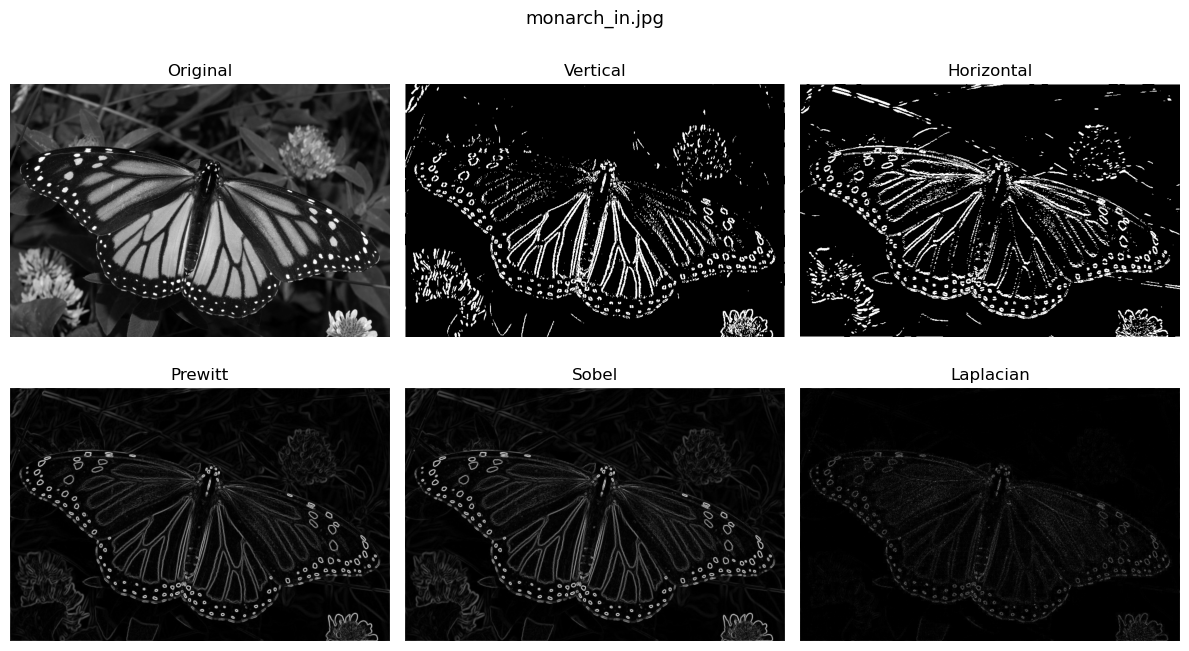

In [6]:
# ── Run
path = img_path
img  = cv2.imread(path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) / 255.0   # float [0,1]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

axes[0].imshow(gray, cmap='gray'); axes[0].set_title("Original")
for ax, (name, fn) in zip(axes[1:], filters.items()):
    ax.imshow(fn(gray), cmap='gray'); ax.set_title(name)

for ax in axes: ax.axis('off')
plt.suptitle(path.split("\\")[-1], fontsize=13)
plt.tight_layout(); plt.show()